# Machine Learning Project 1: Diabetes Diagnosis -- Comparison between Polynomial Rregssion, Random Forest, and AdaBoost

#### Project description:
In this project, we are going to compare the performance of polynomial regression, random forest, and AdaBoost by using the built-in dataset called "load_diabetes" in sklearn.datasets. The aim of this project is to predict indicators for testing disbetes, and this could help early detection and reduce healthcare costs. Different types of graphs are displayed for visualization purpose and regularization is included to prevent overfitting. 

### 1.Upload libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

### 2.Import data

In [11]:
diabetes_diagnosis=load_diabetes()

# Here we retrieve the input from "data" and the output from "target"
x=diabetes_diagnosis.data
y=diabetes_diagnosis.target
print(f"The shape of the inputs is {x.shape}")
print(f"The shape of the outputs is {y.shape}")

The shape of the inputs is (442, 10)
The shape of the outputs is (442,)


Here is the documentation about this dataset:
https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html

In [12]:
# let's check the dataset
print(f"The first ten rows of the inputs: {x[0:10]}")
print(f"The first ten elements of the outputs: {y[0:10]}")

The first ten rows of the inputs: [[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]
 [-0.09269548 -0.04464164 -0.04069594 -0.01944183 -0.06899065 -0.07928784
   0.04127682 -0.0763945  -0.04117617 -0.09634616]
 [-0.04547248  0.05068012 -0.04716281 -0.01599898 -0.04009564 -0.02480001
   0.00077881 -0.03949338 -0.06291688 -0.03835666]
 [ 0.06350368  0.05068012 -0.00189471  0.06662945  0.09061988  0.10891438
   0.02286863  0.

#### Warning:
the dataset load_diabetes has already been preprocessed through data scaling, so don't be surprised that values in the first
and second columns (age and gender) are negative and non-integer.

#### Data description
##### the input contains ten columns:

(1) Age

(2) Gender

(3) BMI(Body Mass Index): BMI is used for measuring a person's weight in relation to their height

(4) BP(Average Blood Pressure)

(5) S1(Total Serum Cholesteral)

(6) S2(Low-Density Lipoproteins)

(7) S3(High-Density Lipoproteins)

(8) S4(Total Cholesterol / HDL Cholesterol Ratio)

(9) S5(Log of Serum Triglycerides Level)

(10) S6(Blood Sugar Level)

##### the output: 
quantitative measure of disease progression one year after the baseline measurements.

In [13]:
# we could also check whether there is any missing value
missing_values_x=np.sum(np.isnan(x),axis=0)
print(f"The number of missing values in the input dataset: {missing_values_x}")

missing_values_y=np.sum(np.isnan(y),axis=0)
print(f"The number of missing values in the output dataset: {missing_values_y}")

The number of missing values in the input dataset: [0 0 0 0 0 0 0 0 0 0]
The number of missing values in the output dataset: 0


### 3.Data visualization

#### (1)Histogram: how is the data of each feature spread?

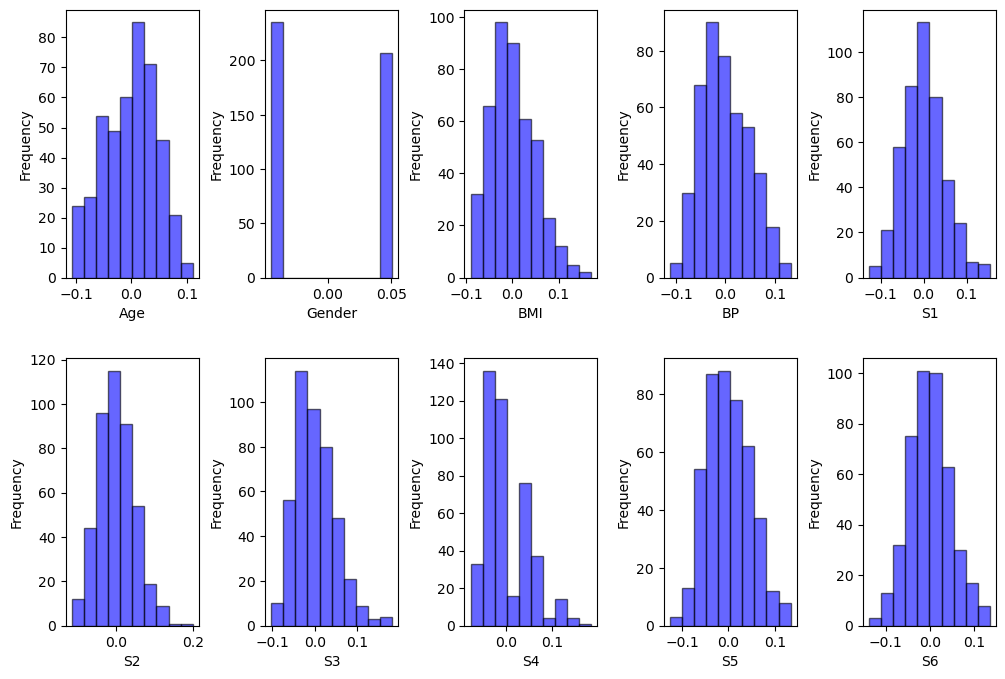

In [14]:
fig,axes=plt.subplots(2,5,figsize=(12,8))
axes=axes.flatten()
features=x.shape[1]
feature_names=["Age","Gender","BMI","BP","S1","S2","S3","S4","S5","S6"]
plt.subplots_adjust(wspace=0.5,hspace=0.3)
for k in range(features):
    ax=axes[k]
    ax.hist(x=x[:,k],color="blue",alpha=0.6,edgecolor="black")
    ax.set_xlabel(feature_names[k])
    ax.set_ylabel("Frequency")
plt.show()

It seems many features such as Age, BMI, BP, S1, S2, S3, S5, S6 follow normal distribution. We could further prove it by drawing QQ plots

#### (2)QQ plot

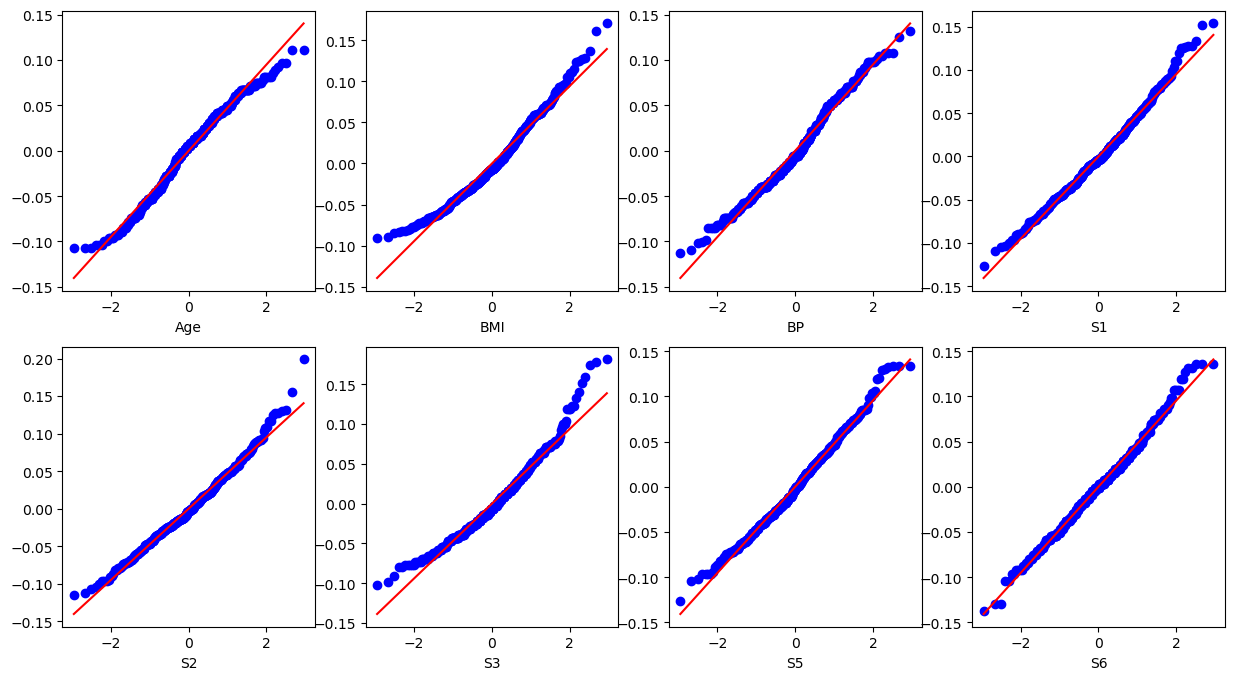

In [15]:
feature_names=["Age","BMI","BP","S1","S2","S3","S5","S6"]
indices=[0,2,3,4,5,6,8,9]

fig,axes=plt.subplots(2,4,figsize=(15,8))
axes=axes.flatten()
for i,index in enumerate(indices):
    ax=axes[i]
    stats.probplot(x[:, index], dist="norm", plot=ax)
    ax.set_title("")
    ax.set_xlabel(feature_names[i])
    ax.set_ylabel("")
plt.show()
    

Based on QQ plots above, we could observe that BP, S1, S2, S5, S6 are mostly likely to follow normal distribution. Regarding the rest features, there exists obvious deviation from the red line in the beginning and tail.

#### (3)Scatter plot

Let's examine the correlation between features and the target

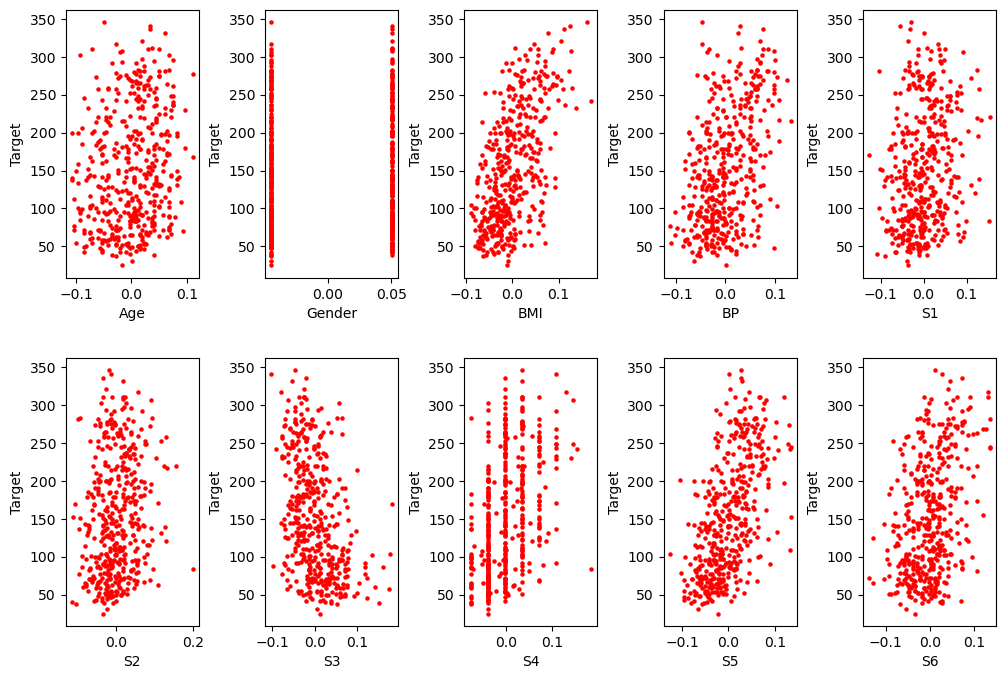

In [16]:
fig,axes=plt.subplots(2,5,figsize=(12,8),)
axes=axes.flatten()
features=x.shape[1]
feature_names=["Age","Gender","BMI","BP","S1","S2","S3","S4","S5","S6"]
plt.subplots_adjust(wspace=0.5,hspace=0.3)
for i in range(features):
    ax=ax[i]
    ax.scatter(x[:,i],y,marker="o",c="red",s=5)
    ax.set_ylabel("Target")
    ax.set_xlabel(feature_names[i])
plt.show()

BMI,BP,S1,S2, S5, S6 seem to have positive correlation with the target, while S3 seems to have negative correlation with it.

#### Correlation coefficient between explanatory variables and the output:

In [17]:
corrcoef_dict={}
features=x.shape[1]
feature_names=["Age","Gender","BMI","BP","S1","S2","S3","S4","S5","S6"]
for j in range(features):
    coreffi=np.corrcoef(x[:,j],y)
    corrcoef_dict[feature_names[j]]=coreffi
print(f"The correlation coefficient between each feature and the target: {corrcoef_dict}")

The correlation coefficient between each feature and the target: {'Age': array([[1.        , 0.18788875],
       [0.18788875, 1.        ]]), 'Gender': array([[1.      , 0.043062],
       [0.043062, 1.      ]]), 'BMI': array([[1.        , 0.58645013],
       [0.58645013, 1.        ]]), 'BP': array([[1.        , 0.44148176],
       [0.44148176, 1.        ]]), 'S1': array([[1.        , 0.21202248],
       [0.21202248, 1.        ]]), 'S2': array([[1.        , 0.17405359],
       [0.17405359, 1.        ]]), 'S3': array([[ 1.        , -0.39478925],
       [-0.39478925,  1.        ]]), 'S4': array([[1.        , 0.43045288],
       [0.43045288, 1.        ]]), 'S5': array([[1.        , 0.56588259],
       [0.56588259, 1.        ]]), 'S6': array([[1.        , 0.38248348],
       [0.38248348, 1.        ]])}


Very weak correlation: Age, Gender, S2

Weak correlation: S1,S3

Moderate correlation: BMI, BP, S4, S5, S6

#### (4) Correlation heatmap

Let's also check the correlation between variables

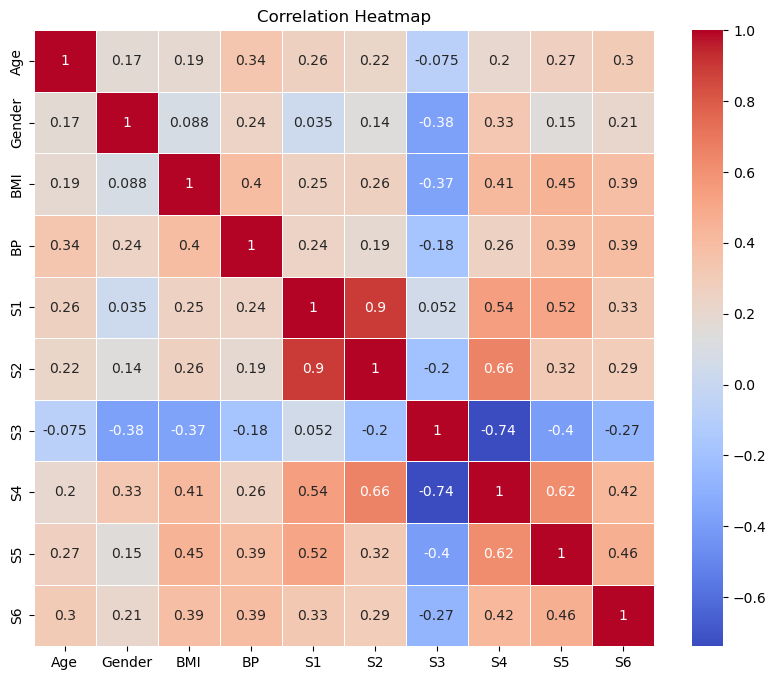

In [18]:
df=pd.DataFrame(x)
x_labels=["Age","Gender","BMI","BP","S1","S2","S3","S4","S5","S6"]
correlation_matrix=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm",linewidths=0.5,xticklabels=x_labels,yticklabels=x_labels)
plt.title("Correlation Heatmap")
plt.show()

Judging from the heatmap above, we can see that S1, S2, S3, and S4 make most contribution to the predictive model while age, gender, BP have the least correlation with other features; therefore we could drop them from the dataset.

### 4.Split data

In [19]:
# In this section, we are going to split data into training set, cross validation set and test set
x_train,x_,y_train,y_=train_test_split(x,y,train_size=0.6,random_state=42)
x_cv,x_test,y_cv,y_test=train_test_split(x_,y_,test_size=0.5,random_state=42)
del x_,y_
print(f"The shape of x_train and y_train： {x_train.shape},{y_train.shape}")
print(f"The shape of x_cv and y_cv: {x_cv.shape},{y_cv.shape} ")
print(f"The shape of x_test and y_test: {x_test.shape},{y_test.shape}")

The shape of x_train and y_train： (265, 10),(265,)
The shape of x_cv and y_cv: (88, 10),(88,) 
The shape of x_test and y_test: (89, 10),(89,)


### 5.Polynomial regression model

In this section, we are going to build a regression model with polynomial features. We need to the deceide the degree of polynomial features

In [20]:
train_mses=[]
cv_mses=[]
test_mses=[]
r2_scores=[]
models=[]
scalers=[]
for degree in range(1,11):
    poly=PolynomialFeatures(degree=degree,include_bias=False)
    x_train_mapped=poly.fit_transform(x_train)

    scaler=StandardScaler()
    x_train_mapped_scaled=scaler.fit_transform(x_train_mapped)
    scalers.append(scaler)

    lasso_model=Lasso(alpha=0.1)
    lasso_model.fit(x_train_mapped_scaled,y_train)
    models.append(lasso_model)

    y_train_estimated=lasso_model.predict(x_train_mapped_scaled)
    train_mse=mean_squared_error(y_train_estimated,y_train)
    train_mses.append(train_mse)

    x_cv_mapped = poly.fit_transform(x_cv)
    x_cv_mapped_scaled = scaler.transform(x_cv_mapped)

    lasso_model.fit(x_cv_mapped_scaled, y_cv)
    y_cv_estimated = lasso_model.predict(x_cv_mapped_scaled)
    cv_mse=mean_squared_error(y_cv_estimated,y_cv)
    cv_mses.append(cv_mse)

    x_test_mapped=poly.fit_transform(x_test)
    x_test_mapped_scaled=scaler.transform(x_test_mapped)

    lasso_model.fit(x_test_mapped_scaled,y_test)
    y_test_estimated=lasso_model.predict(x_test_mapped_scaled)
    test_mse=mean_squared_error(y_test_estimated,y_test)
    test_mses.append(test_mse)
    r2_score_test=r2_score(y_test_estimated,y_test)
    r2_scores.append(r2_score_test)


print(f"The list of MSEs of the training set: {train_mses}")
print(f"The list of MSEs of the cross validation set: {cv_mses}")
print(f"The list of MSEs of the test set: {test_mses}")
print(f"The list of R-Squared values of the test set: {r2_scores}")

The list of MSEs of the training set: [2948.74241406386, 2395.1612952060113, 1201.8354457131998, 290.219002224747, 184.52211391300787, 168.34102126076462, 163.8540306488132, 162.37933893101922, 160.61844531095102, 162.12391421582421]
The list of MSEs of the cross validation set: [2170.8181598577844, 1208.7728681976294, 31.34929038028928, 16.57063901206335, 14.233808031035032, 13.842668310885472, 13.729198538069312, 13.549695751558403, 13.155119620417919, 13.116384054884916]
The list of MSEs of the test set: [2666.2837477957055, 934.3622773295524, 24.568917232827037, 11.993919800138103, 11.42982539962965, 10.96683692848849, 10.53875520244641, 10.274543363901323, 10.323776500144474, 10.259088042687228]
The list of R-Squared values of the test set: [0.13817221787472955, 0.7994469250866708, 0.9955384570264639, 0.9978436723442642, 0.9979490107195886, 0.9980337966298531, 0.998111471430999, 0.9981596776503402, 0.9981509644081423, 0.9981634566592308]


#### Data visualization of train_mses and cv_mses

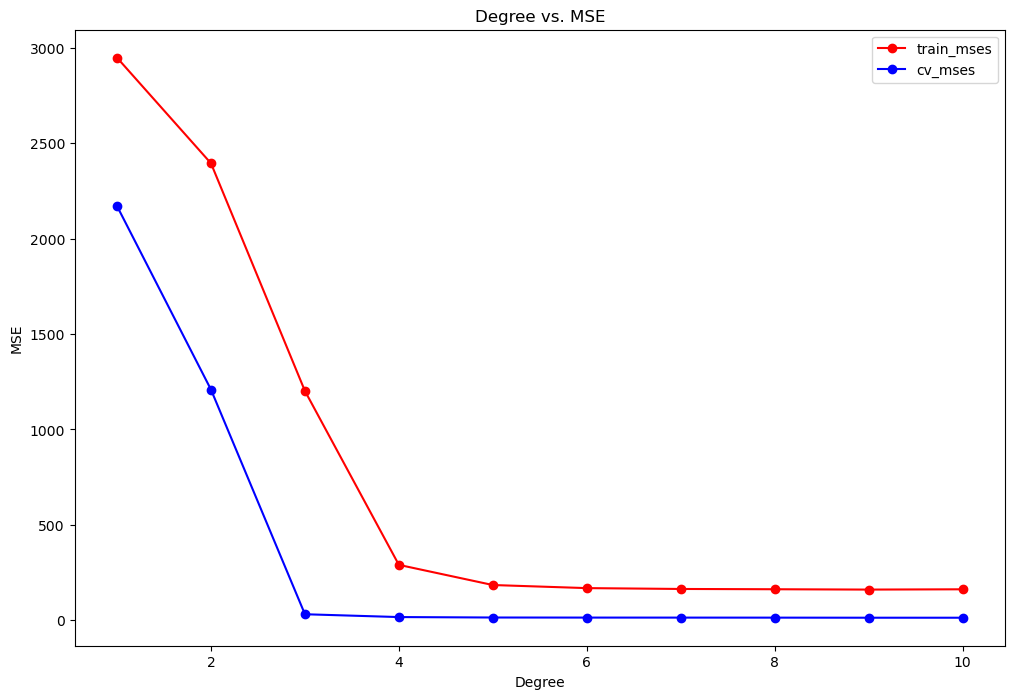

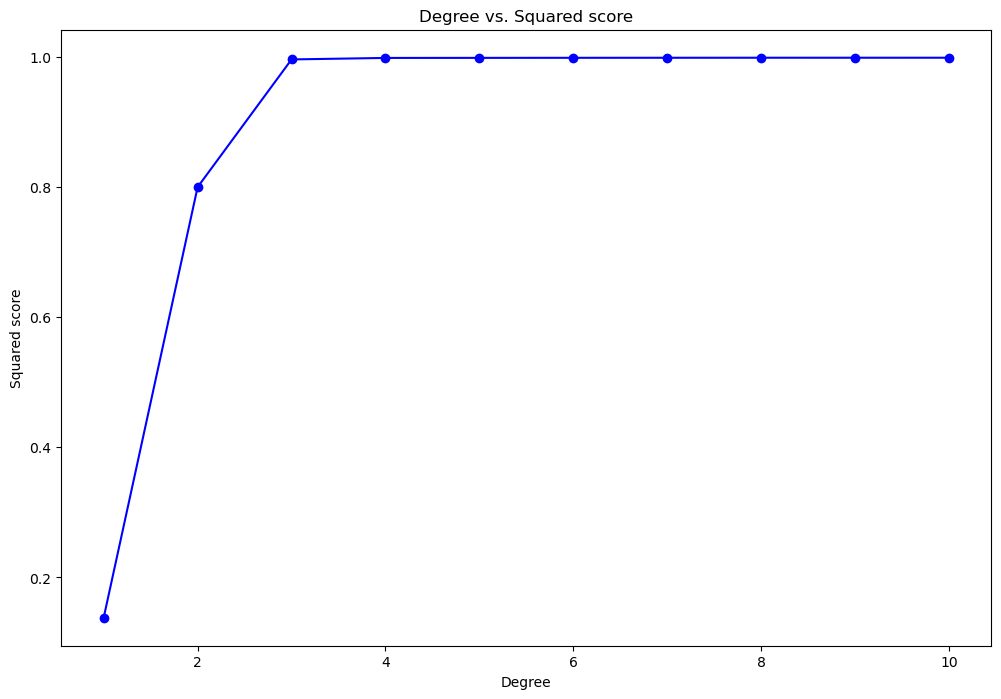

In [21]:
degrees=range(1,11)
fig.ax=plt.subplots(1,1,figsize=(12,8))
plt.plot(degrees,train_mses,marker="o",c="red",label="train_mses")
plt.plot(degrees,cv_mses,marker="o",c="blue",label="cv_mses")
plt.xlabel("Degree")
plt.ylabel("MSE")
plt.title("Degree vs. MSE")
plt.legend()
plt.show()

fig.ax=plt.subplots(1,1,figsize=(12,8))
plt.plot(degrees,r2_scores,marker="o",c="blue",label="r2_scores of the test set")
plt.xlabel("Degree")
plt.ylabel("Squared score")
plt.title("Degree vs. Squared score")
plt.show()

In [27]:
# let's find a proper degree for the polynomial model

degree=2
print(f"The proper degree is {degree} ")
print(f"The corresponding R-squared of the test set is {r2_scores[degree-1]}")

The proper degree is 2 
The corresponding R-squared of the test set is 0.7994469250866708


In conclusion: it seems regression model with polynomial features up to degree 10 fits the data pretty well.

### 6.Random forest model

We could also compare polynomial regression model with random forest model

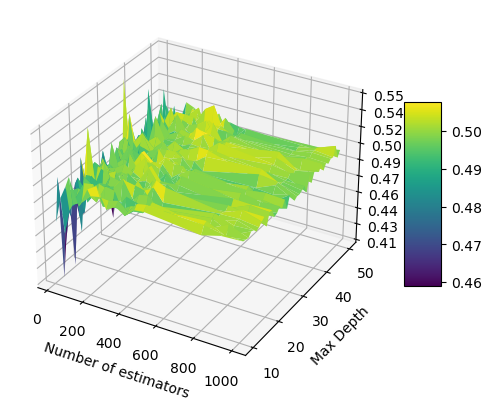

In [28]:
num_estimators=[20,50,80,100,150,200,250,300,350,400,450,500,800,900,1000]
max_depth=np.arange(10,51)
X,Y=np.meshgrid(num_estimators,max_depth) # for 3d data visualization purpose


# let's start to build a random forest model and compare the optimum number of estimators and the best maximum depth.
rf_R2=np.zeros((len(num_estimators),len(max_depth)))
for i,n_estimators in enumerate(num_estimators):
    for j,depth in enumerate(max_depth):
        rf_model=RandomForestRegressor(n_estimators=n_estimators,max_depth=depth)
        rf_model.fit(x_train,y_train)
        y_cv_pred=rf_model.predict(x_cv)
        r2_score_cv=r2_score(y_cv,y_cv_pred)
        rf_R2[i,j]=r2_score_cv

        
# we could include a 3D plot
fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")
threed_plot=ax.plot_surface(X,Y,rf_R2.T,cmap="viridis")
ax.set_xlabel("Number of estimators")
ax.set_ylabel("Max Depth")
ax.set_zlabel("R Squared Score")
ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter("{x:.02f}")
fig.colorbar(threed_plot,shrink=0.5,aspect=5)
plt.show()
        

Based  2D numpy array rf_R2, let's search for the best model!

In [29]:
best_R2_score=np.max(rf_R2)
print(best_R2_score)

0.5504314097640914


The best R2_socre shows this random forest model fit data moderately. Moreover, I don't suggest to set n_estimators and max_depth too high since it is computationally too inefficient. Let's try AdaBoost.

### 7.AdaBoost

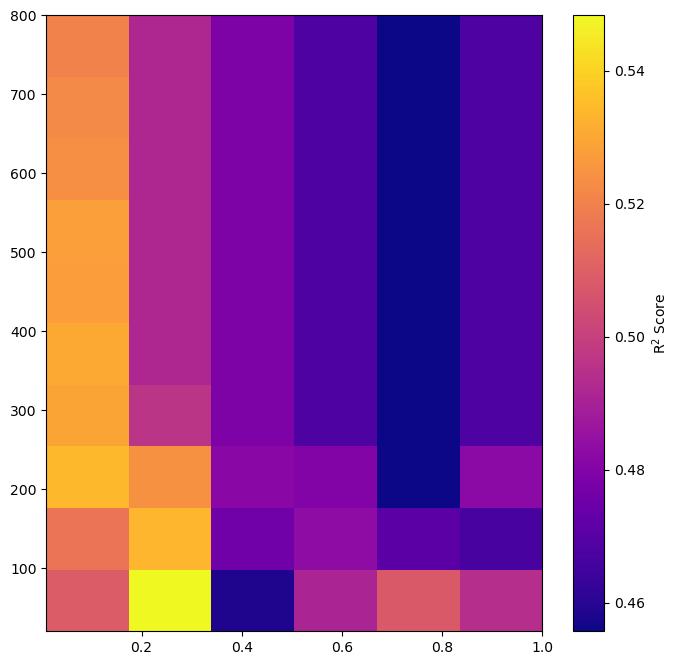

In [34]:
estimator_values=[20,50,100,200,300,400,500,600,700,800]
learning_rates=[0.01,0.1,0.2,0.4,0.5,1]
base_regressor=DecisionTreeRegressor(max_depth=3)

r2_grid=np.zeros((len(estimator_values),len(learning_rates)))

for i,estimate_value in enumerate(estimator_values):
    for j,rate in enumerate(learning_rates):
        adaboost_regress=AdaBoostRegressor(
        base_estimator=base_regressor,
        n_estimators=estimate_value,
        learning_rate=rate,
        random_state=42
        )
        adaboost_regress.fit(x_train,y_train)
        y_pred_cv2=adaboost_regress.predict(x_cv)
        r2_score_ada=r2_score(y_cv,y_pred_cv2)
        r2_grid[i,j]=r2_score_ada

# let's plot a heat map
plt.figure(figsize=(8,8))
plt.imshow(r2_grid,cmap="plasma",extent=[0.01,1,20,800],origin="lower",aspect="auto")
cb=plt.colorbar()
cb.set_label("R$^2$ Score")
plt.show()

In [35]:
# the best R Squared Score
best_R2_score_ada=np.max(r2_grid)
print(best_R2_score_ada)

0.5483144360416833


 ### 8.Conclusion

##### Model comparison:
In the last session, we could compare Polynomail regression model, Decision tree model and Adaboost model.

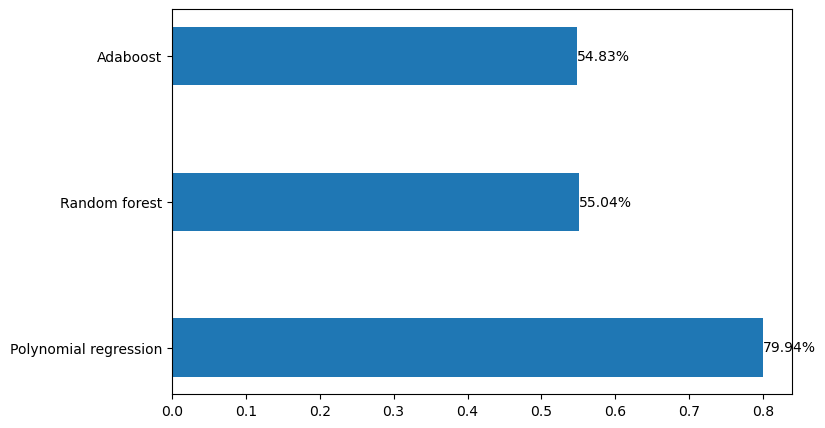

In [36]:
R2_scores_all=[r2_scores[degree-1],best_R2_score,best_R2_score_ada]
model_types=["Polynomial regression","Random forest","Adaboost"]

fig,ax=plt.subplots(1,1,figsize=(8,5))
hb=ax.barh(y=model_types,width=R2_scores_all,height=0.4)
ax.bar_label(hb,labels=[f"{i*100:.2f}%" for i in R2_scores_all])
plt.show()

#### So Polynomial regression model is the winner!